In [1]:
import os
import glob
import pandas as pd
from datetime import datetime

In [2]:
working_folder = "D:/Ctym/p/p174_GemeloDigital_Leon/1_Infobase/Datos Telefonía NOMMON/00275/"
file_name = '00275_odmatrix.csv.gz'
output_folder = 'D:/Ctym/p/p174_GemeloDigital_Leon/5_Trabajo/dev'
gz_file = os.path.join(working_folder,file_name)
dateparse = lambda x: datetime.strptime(x, '%Y-%m-%d')

# Read main table
dtypes = {
    'date': 'object',
    'period': 'string',
    'origin': 'int64',
    'destination': 'int64',
    'country': 'string',
    'origin_purpose': 'string',
    'destination_purpose': 'string',
    'residence': 'string',
    'distance': 'string',
    'income': 'string',
    'age': 'string',
    'gender': 'string',
    'professional': 'string',
    'trips': 'float64',
    'trips_km': 'float64'
}

raw_data = pd.read_csv(gz_file, sep = '|', dtype= dtypes, encoding='utf-8')
raw_data['date'] = pd.to_datetime(raw_data['date'], format = "%Y-%m-%d")
raw_data.info()
raw_data.head(5)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44118815 entries, 0 to 44118814
Data columns (total 15 columns):
 #   Column               Dtype         
---  ------               -----         
 0   date                 datetime64[ns]
 1   period               string        
 2   origin               int64         
 3   destination          int64         
 4   country              string        
 5   origin_purpose       string        
 6   destination_purpose  string        
 7   residence            string        
 8   distance             string        
 9   income               string        
 10  age                  string        
 11  gender               string        
 12  professional         string        
 13  trips                float64       
 14  trips_km             float64       
dtypes: datetime64[ns](1), float64(2), int64(2), string(10)
memory usage: 4.9 GB


,date,period,origin,destination,country,origin_purpose,destination_purpose,residence,distance,income,age,gender,professional,trips,trips_km
0,2023-01-08,PH00,1,1,Spain,H,O,24,D0,I4,65-100,female,No,6.843,1.149
1,2023-01-08,PH00,1,1,Spain,H,O,24,D0,I4,65-100,male,No,3.708,2.354
2,2023-01-08,PH00,1,1,Spain,NF,H,24,D0,I4,25-45,male,No,3.931,1.981
3,2023-01-08,PH00,1,1,Spain,NF,H,24,D0,I4,65-100,male,No,3.708,1.577
4,2023-01-08,PH00,1,1,Spain,NF,NF,01,D0,I4,25-45,male,No,4.234,1.831


1. H - Propósito del viaje "casa" (del inglés home). Un viaje con propósito en origen con identificador H se ha detectado con origen en la ubicación identificada como casa y un viaje con propósito en destino con identificador H se ha detectado con destino a la ubicación identificada como casa.
2. W - Propósito del viaje "trabajo" (del inglés work). Un viaje con propósito en origen con identificador W se ha detectado con origen en la ubicación identificada como trabajo y un viaje con propósito en destino con identificador W se ha detectado con destino a la ubicación identificada como trabajo.
3. O - Propósito del viaje "otra ubicación frecuente" (del inglés other). Un viaje con propósito en origen con identificador O se ha detectado con origen en una ubicación identificada como frecuente que no es ni la casa ni el trabajo y un viaje con propósito en destino con identificador O se ha detectado con destino a una ubicación identificada como frecuente que no es ni la casa ni el trabajo.
4. NF - Propósito del viaje "ubicación no frecuente" (del inglés non-frequent). Un viaje con propósito en origen con identificador NF se ha detectado con origen en una ubicación identificada como no frecuente y un viaje con propósito en destino con identificador NF se ha detectado con destino a una ubicación identificada como no frecuente.


In [3]:
# Trip purpose transformation
# When a trip has Home "H" as origin or destination, the trip purpose will always be the other trip purpose.

def trip_purpose(row):
    if pd.isna(row['origin_purpose']) or pd.isna(row['destination_purpose']):
        return ('N/A')
    if row['origin_purpose'] == 'H':
        return row['destination_purpose']
    elif row['destination_purpose'] == 'H':
        return row['origin_purpose']
    else:
        return row['destination_purpose']

raw_data['trip_purpose'] = raw_data.apply(trip_purpose, axis = 1)

u_purpose = raw_data['trip_purpose'].unique()

assert 'H' not in u_purpose, (
    f"There are still some trips labelled as 'H'"
)

In [4]:
# The fields 'ID' and 'Descrip' from the following JSON file contain the key-value pairs for the origin and destination codes
import json

json_files = glob.glob(os.path.join(working_folder,'*.json'))
with open (json_files[0], 'r', encoding= 'utf-8') as f:
	zoning = json.load(f)

	# Extract the 'features' list.
	zoning_dict = {
		  feature["properties"]["ID"]: feature["properties"]["Descrip"]
		  for feature in zoning.get("features", [])
	}

# Convert the dictionary to a pandas Series
zoning_series = pd.Series(zoning_dict, name='area_name')
display(zoning_series.unique())

data = raw_data.copy()
# Map the origin and destination names
data['origin_gr'] = data['origin'].map(zoning_series)
data['destination_gr'] = data['destination'].map(zoning_series)

display(data.head(2))


array(['Comunidades autónomas insulares', 'Area Metropolitana León',
       'León', 'Desagregados de Zonif MIT colindantes',
       'Resto de provincias peninsulares', 'Ciudades Autónomas',
       'Provincias exteriores limítrofes', 'Resto CYL', 'Resto provincia'],
      dtype=object)

,date,period,origin,destination,country,origin_purpose,destination_purpose,residence,distance,income,age,gender,professional,trips,trips_km,trip_purpose,origin_gr,destination_gr
0,2023-01-08,PH00,1,1,Spain,H,O,24,D0,I4,65-100,female,No,6.843,1.149,O,León,León
1,2023-01-08,PH00,1,1,Spain,H,O,24,D0,I4,65-100,male,No,3.708,2.354,O,León,León


In [5]:
# Create a new column grouping the residence codes from the residence column
def map_residence(value):
    if pd.isna(value):
        return 'Unknown'
    if value == '24':
        return 'provincia León'
    elif value in ['27', '32', '33', '34', '39', '47', '49']:
        return 'limítrofes León'
    elif value in ['5', '9', '37', '40', '42']:
        return 'resto de CyL'
    else:
        return 'resto de España y extranjero'

# Apply the function to create the new column
data['residence_gr'] = data['residence'].apply(map_residence)
display(data)


,date,period,origin,destination,country,origin_purpose,destination_purpose,residence,distance,income,age,gender,professional,trips,trips_km,trip_purpose,origin_gr,destination_gr,residence_gr
0,2023-01-08,PH00,1,1,Spain,H,O,24,D0,I4,65-100,female,No,6.843,1.149,O,León,León,provincia León
1,2023-01-08,PH00,1,1,Spain,H,O,24,D0,I4,65-100,male,No,3.708,2.354,O,León,León,provincia León
2,2023-01-08,PH00,1,1,Spain,NF,H,24,D0,I4,25-45,male,No,3.931,1.981,NF,León,León,provincia León
3,2023-01-08,PH00,1,1,Spain,NF,H,24,D0,I4,65-100,male,No,3.708,1.577,NF,León,León,provincia León
4,2023-01-08,PH00,1,1,Spain,NF,NF,01,D0,I4,25-45,male,No,4.234,1.831,NF,León,León,resto de España y extranjero
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44118810,2023-12-04,PH23,99,99,Spain,W,H,37,D3,I3,65-100,male,No,1.429,12.856,W,Resto CYL,Resto CYL,resto de CyL
44118811,2023-12-04,PH23,99,99,Spain,W,H,37,D4,I2,45-65,male,No,2.446,25.849,W,Resto CYL,Resto CYL,resto de CyL
44118812,2023-12-04,PH23,99,99,Spain,W,H,37,D4,I2,45-65,male,Urban,2.360,36.574,W,Resto CYL,Resto CYL,resto de CyL
44118813,2023-12-04,PH23,99,99,Spain,W,H,37,D5,I2,65-100,male,No,1.846,71.888,W,Resto CYL,Resto CYL,resto de CyL


In [6]:
# Groupby to reduce data dimension
gr_criteria = ['date', 'period', 'origin_gr', 'destination_gr', 'trip_purpose', 'residence_gr', 'distance', 'income', 'age', 'gender']
data[gr_criteria] = data[gr_criteria].fillna("Unknown")
trips_before = data['trips'].sum()

gr_data = data.groupby(gr_criteria).agg(
			trips=('trips', 'sum'),
			trips_km=('trips_km', 'sum')
		).reset_index()

trips_after = gr_data['trips'].sum()
assert round(trips_before, 4) == round(trips_after, 4), (
    f'The number of trips before is:{trips_before} and the number of trips after the groupby is {trips_after}. Check formulas'
)
display(gr_data)

,date,period,origin_gr,destination_gr,trip_purpose,residence_gr,distance,income,age,gender,trips,trips_km
0,2023-01-08,PH00,Area Metropolitana León,Area Metropolitana León,N/A,Unknown,D1,Unknown,Unknown,Unknown,1.260,2.145
1,2023-01-08,PH00,Area Metropolitana León,Area Metropolitana León,NF,limítrofes León,D0,I2,45-65,female,3.145,1.691
2,2023-01-08,PH00,Area Metropolitana León,Area Metropolitana León,NF,limítrofes León,D0,I2,45-65,male,2.308,2.005
3,2023-01-08,PH00,Area Metropolitana León,Area Metropolitana León,NF,limítrofes León,D1,I2,45-65,male,2.308,3.248
4,2023-01-08,PH00,Area Metropolitana León,Area Metropolitana León,NF,limítrofes León,D2,I2,45-65,male,2.044,4.381
...,...,...,...,...,...,...,...,...,...,...,...,...
2247886,2023-12-04,PH23,Resto provincia,Resto provincia,W,provincia León,D4,I4,45-65,female,3.109,53.342
2247887,2023-12-04,PH23,Resto provincia,Resto provincia,W,provincia León,D5,I2,0-25,female,10.346,228.199
2247888,2023-12-04,PH23,Resto provincia,Resto provincia,W,provincia León,D5,I3,25-45,female,1.527,33.289
2247889,2023-12-04,PH23,Resto provincia,Resto provincia,W,provincia León,D5,I3,25-45,male,3.290,110.625


In [7]:
# Auxiliary tables
dist_file = glob.glob(os.path.join(working_folder, "*distances.txt"))
distance_df = pd.read_csv(dist_file[0], sep = '|', index_col='ID')

periods_file = glob.glob(os.path.join(working_folder, "*periods.txt"))
periods_df = pd.read_csv(periods_file[0], sep = '|', index_col='ID')

income_file = glob.glob(os.path.join(working_folder, "*income.txt"))
income_df = pd.read_csv(income_file[0], sep='|', index_col='ID')

# display(distance_df)
# display(periods_df)
# display(income_df)

# Merge columns from auxiliary tables. Use righ_index = True to prevent column duplications
period_name = gr_data['period'].map(periods_df['periods'])
distance_name = gr_data['distance'].map(distance_df['range'])
income_name = gr_data['income'].map(income_df['range'])

gr_data['period_label'] = period_name
gr_data['distance_label'] = distance_name
gr_data['income_label'] = income_name
display(gr_data)

,date,period,origin_gr,destination_gr,trip_purpose,residence_gr,distance,income,age,gender,trips,trips_km,period_label,distance_label,income_label
0,2023-01-08,PH00,Area Metropolitana León,Area Metropolitana León,N/A,Unknown,D1,Unknown,Unknown,Unknown,1.260,2.145,00:00:00-00:59:59,1000-2000,NaN
1,2023-01-08,PH00,Area Metropolitana León,Area Metropolitana León,NF,limítrofes León,D0,I2,45-65,female,3.145,1.691,00:00:00-00:59:59,0-1000,10000-11999.9999
2,2023-01-08,PH00,Area Metropolitana León,Area Metropolitana León,NF,limítrofes León,D0,I2,45-65,male,2.308,2.005,00:00:00-00:59:59,0-1000,10000-11999.9999
3,2023-01-08,PH00,Area Metropolitana León,Area Metropolitana León,NF,limítrofes León,D1,I2,45-65,male,2.308,3.248,00:00:00-00:59:59,1000-2000,10000-11999.9999
4,2023-01-08,PH00,Area Metropolitana León,Area Metropolitana León,NF,limítrofes León,D2,I2,45-65,male,2.044,4.381,00:00:00-00:59:59,2000-5000,10000-11999.9999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2247886,2023-12-04,PH23,Resto provincia,Resto provincia,W,provincia León,D4,I4,45-65,female,3.109,53.342,23:00:00-23:59:59,10000-20000,15000-inf
2247887,2023-12-04,PH23,Resto provincia,Resto provincia,W,provincia León,D5,I2,0-25,female,10.346,228.199,23:00:00-23:59:59,20000-50000,10000-11999.9999
2247888,2023-12-04,PH23,Resto provincia,Resto provincia,W,provincia León,D5,I3,25-45,female,1.527,33.289,23:00:00-23:59:59,20000-50000,12000-14999.9999
2247889,2023-12-04,PH23,Resto provincia,Resto provincia,W,provincia León,D5,I3,25-45,male,3.290,110.625,23:00:00-23:59:59,20000-50000,12000-14999.9999


In [8]:
display(sorted(data['origin_gr'].unique()))

['Area Metropolitana León',
 'Ciudades Autónomas',
 'Comunidades autónomas insulares',
 'Desagregados de Zonif MIT colindantes',
 'León',
 'Provincias exteriores limítrofes',
 'Resto CYL',
 'Resto de provincias peninsulares',
 'Resto provincia']

In [9]:
import matplotlib.pyplot as plt

def plot_stacked_bar(data, column_name, origin_gr = None, destination_gr = None):
	"""
	Plots a 100% stacked bar chart for the specified column with date as the X-axis.
	
	Args:
		data (pd.DataFrame): The input DataFrame.
		origin_gr: Origin areas to show.
		destination_gr: Destination areas to show.
		column_name (str): The column to plot as a 100% stacked bar chart.
	"""

	# Slice the data
	if origin_gr is not None:
		data = data[data['origin_gr'].isin(origin_gr)]  # Filter by provided origin_gr
	
	if destination_gr is not None:
		data = data[data['destination_gr'].isin(destination_gr)]  # Filter by provided destination_gr

	# Group by date and the specified column, summing the trips
	grouped = data.groupby(['date', column_name])['trips'].sum().reset_index()
	
	# Pivot the table to have the column values as separate columns
	pivot_table = grouped.pivot(index='date', columns=column_name, values='trips').fillna(0)
	
	# Normalize each row to represent percentages
	normalized = pivot_table.div(pivot_table.sum(axis=1), axis=0) * 100

	# Plot the data
	normalized.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
	
	plt.title(f"100% Stacked Bar Chart for {column_name}")
	plt.ylabel("Percentage")
	plt.xlabel("Date")
	plt.legend(title=column_name, bbox_to_anchor=(1.05, 1), loc='upper left')
	plt.tight_layout()
	plt.show()


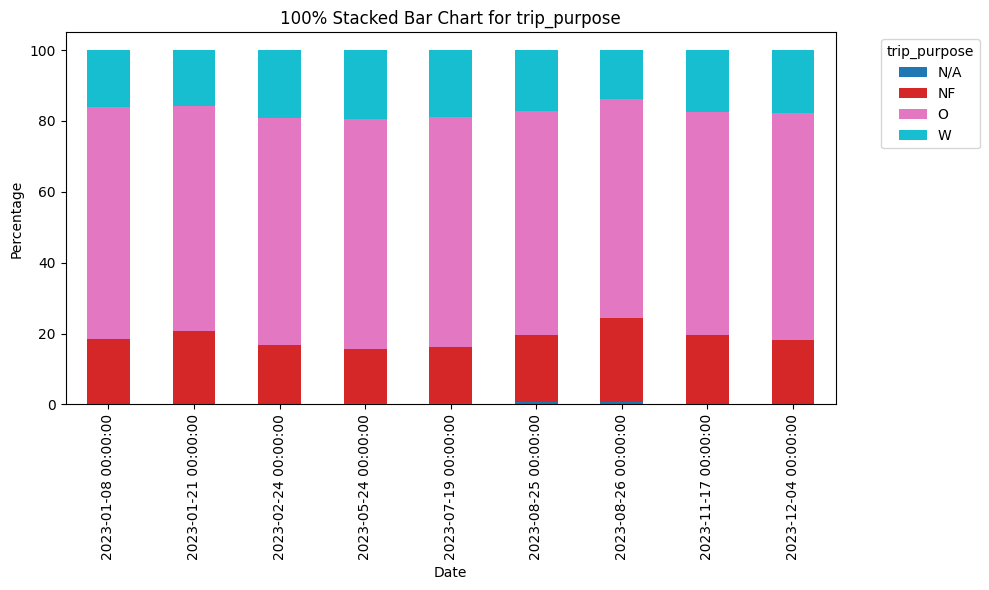

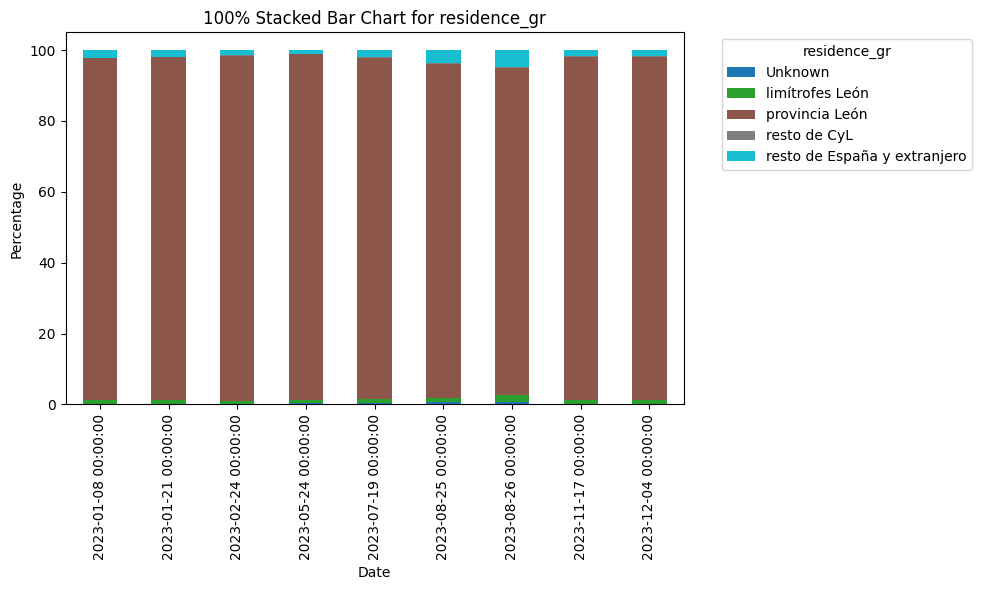

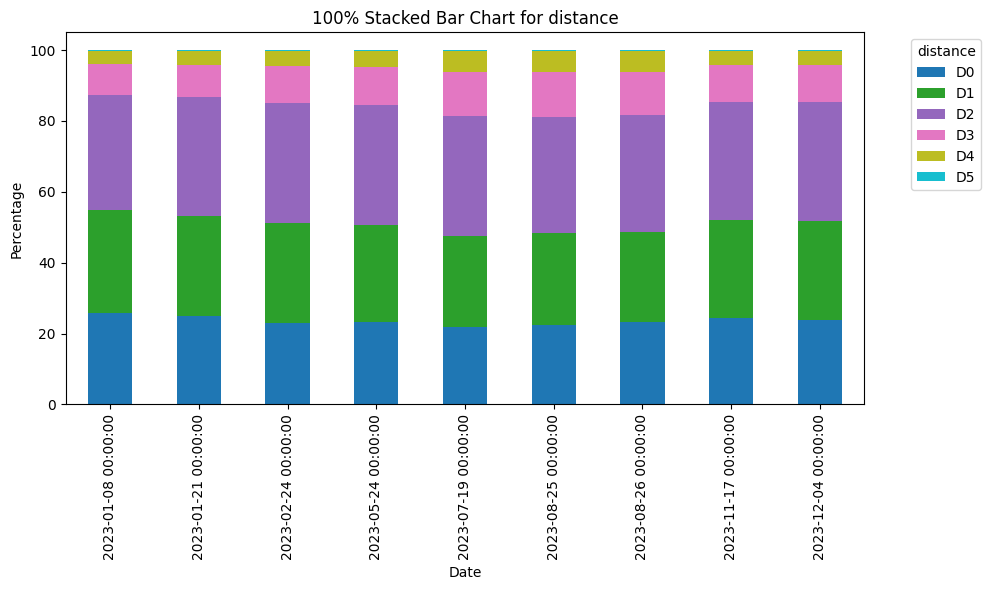

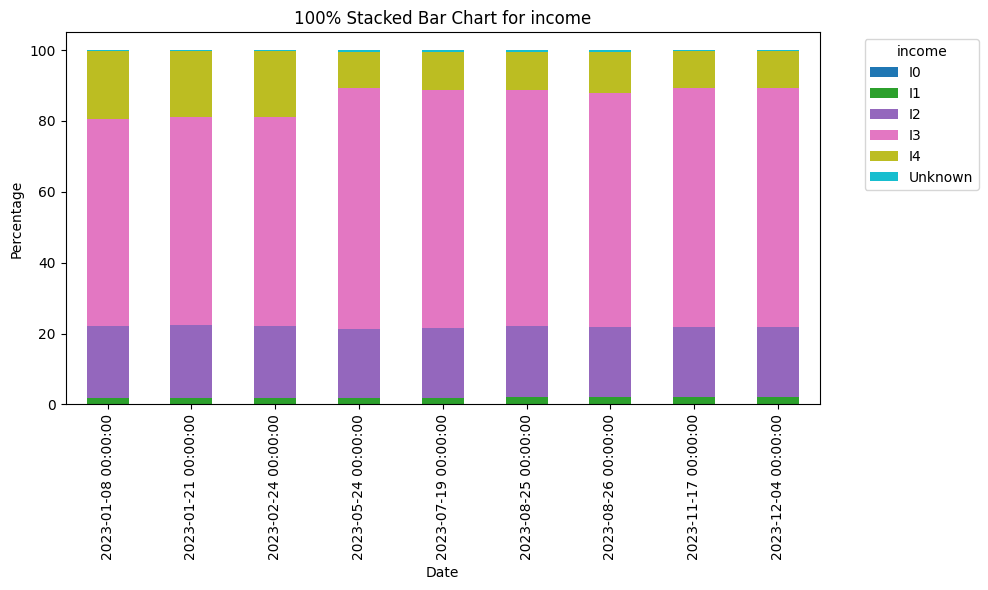

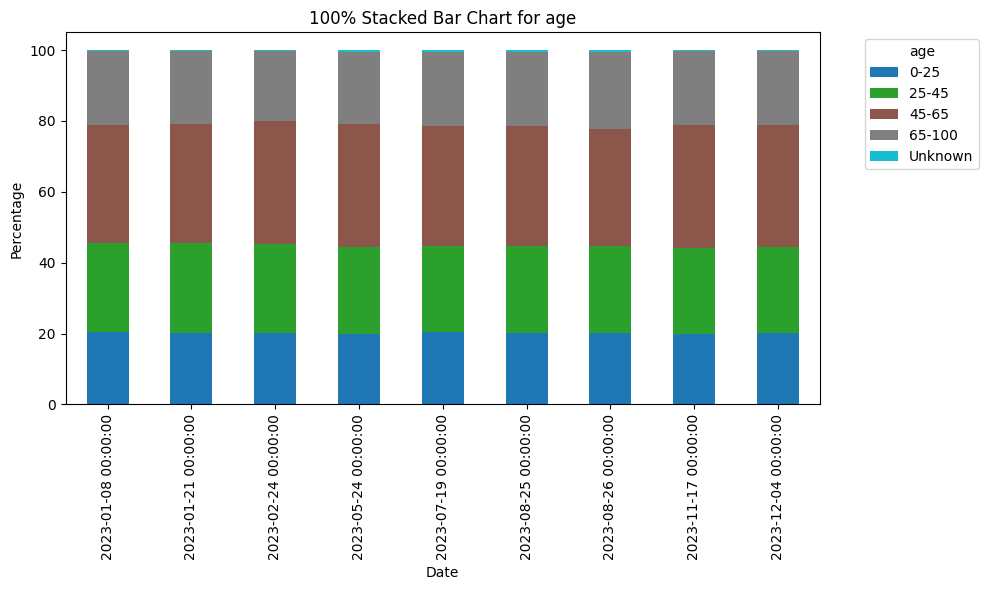

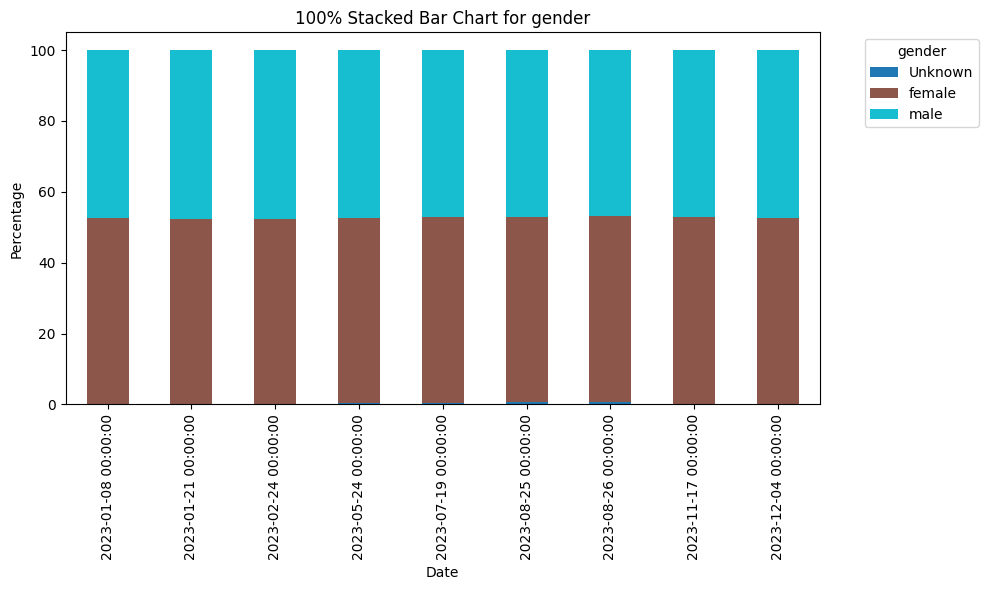

In [10]:
plot_stacked_bar(gr_data, 'trip_purpose',['Area Metropolitana León','León'],['Area Metropolitana León','León'])
plot_stacked_bar(gr_data,'residence_gr',['Area Metropolitana León','León'],['Area Metropolitana León','León'])
plot_stacked_bar(gr_data,'distance',['Area Metropolitana León','León'],['Area Metropolitana León','León'])
plot_stacked_bar(gr_data,'income',['Area Metropolitana León','León'],['Area Metropolitana León','León'])
plot_stacked_bar(gr_data,'age',['Area Metropolitana León','León'],['Area Metropolitana León','León'])
plot_stacked_bar(gr_data,'gender',['Area Metropolitana León','León'],['Area Metropolitana León','León'])


In [11]:
# Añadir el orden en el que se deben mostrar las zonas del estudio
orden_zonas = pd.read_csv(os.path.join(output_folder,'orden_zonas.csv'), encoding='utf-8', index_col= 'nombre')

origin = gr_data['origin_gr'].map(orden_zonas['orden'])
dest = gr_data['destination_gr'].map(orden_zonas['orden'])

gr_data['origen_ordenado'] = origin
gr_data['destino_ordenado'] = dest

In [12]:
output_file = os.path.join(output_folder,'datos_móviles.csv')
gr_data.to_csv(output_file, encoding='utf-8', index= False)

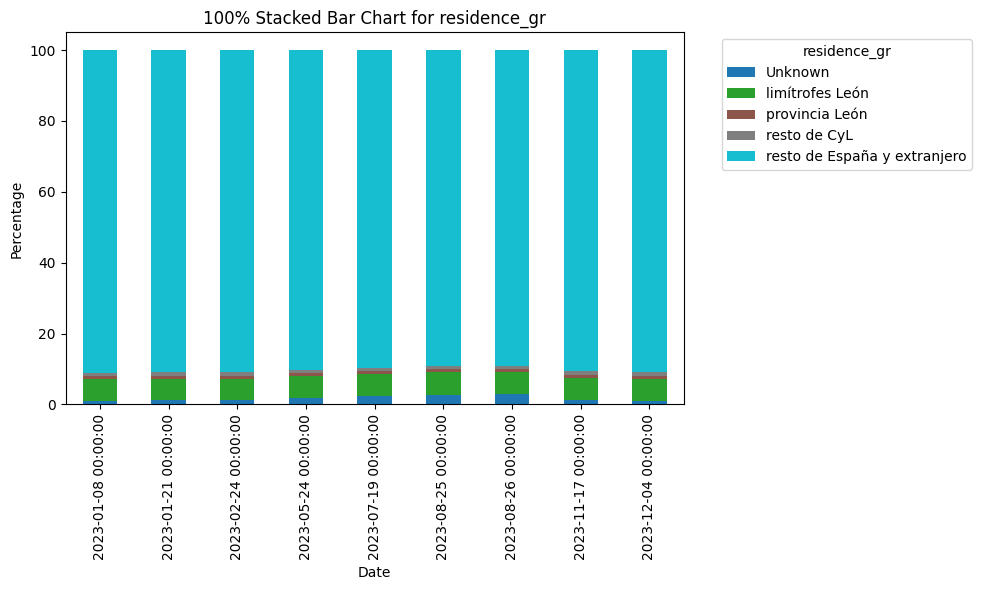

In [13]:
plot_stacked_bar(gr_data,'residence_gr')
